# Polynomial Regression

Polynomial Regression is a form of linear regression in which the relationship between the independent variable x and dependent variable y is modeled as an nth degree polynomial. Polynomial regression fits a nonlinear relationship between the value of x and the corresponding conditional mean of y, denoted E(y |x), and has been used to describe nonlinear phenomena such as the growth rate of tissues, the distribution of carbon isotopes in lake sediments, and the progression of disease epidemics.


### **y = x - 2 * (x ** 2) + np.random.normal(-3, 3, 20)**

This code generates a quadratic dataset with random noise.
It builds a dependent variable vector (y) using the NumPy library.
The output contains a sample of 20 noisy points.
### **1. Define the quadratic trend**
- Computes a deterministic mathematical baseline curve.
- Uses the formula f(x) = x - 2x^2.
- Models a downward-opening parabolic path shape.
- Requires a matching predefined input array x.
### **2. Generate Gaussian random noise**
- Calls the numpy.random.normal function tool.
- Specifies a distribution mean (mu) = -3.
- Sets a standard deviation (sigma = 3).
- Returns an array containing 20 elements.
### **3. Add noise to trend**
- Sums the baseline curve and noise.
- Shifts data points down by 3 units.
- Follows the statistical model equation:
- y=x-2x^{2}+epsilon 
- Defines the random error distribution as:
- epsilon~N(-3,3^{2})

- The line x = 2 - 3 * np.random.normal(0, 1, 20) creates an array of 20 elements drawn from a normal (Gaussian) distribution.
- np.random.normal(0, 1, 20) generates 20 samples from a standard normal distribution with a mean (mu ) of 0 and a standard deviation sigma of 1.
- Multiplying by (-3) stretches the distribution to a standard deviation of (3).
- Adding (2) shifts the entire distribution rightward.
- Consequently, the final random variable (x) follows a normal distribution:(mu =2,sigma ^{2}=9)

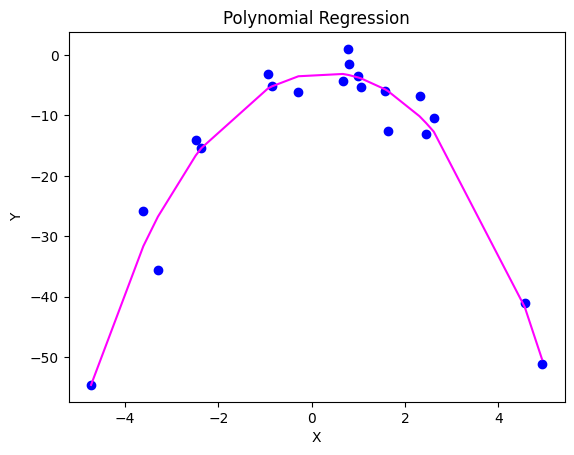

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import operator

# Step 1: Create Dummy Data
np.random.seed(0)
x = 2 - 3 * np.random.normal(0, 1, 20)
y = x - 2 * (x ** 2) + np.random.normal(-3, 3, 20)

# Reshaping for the model
x = x[:, np.newaxis]
y = y[:, np.newaxis]

# Step 2: Polynomial Transformation
degree = 4  # Degree of the polynomial
poly_features = PolynomialFeatures(degree=degree)
x_poly = poly_features.fit_transform(x)

# Step 3: Train Linear Regression Model
model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

# Step 4: Plotting the results
plt.scatter(x, y, color='blue')
sorted_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x, y_poly_pred), key=sorted_axis)
x, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='magenta')
plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

---

In [ ]:
x = 2 - 3 * np.random.normal(0, 1, 20)
y = x - 2 * (x ** 2) + np.random.normal(-3, 3, 20)

In [4]:
x

array([ 5.1456589 ,  6.26005381,  7.11881057, -3.85232619,  3.52895655,
        3.3142229 ,  5.75838608, -0.33247107,  6.84169354,  2.63822084,
        4.68639968,  0.83929251,  3.53241541,  5.54189655,  2.08454669,
        0.71500439,  1.80044833,  1.09258431,  3.90296628,  3.0882235 ])

Trained Coefficients: [ 0.82196856 -1.91210984  0.49684817]
Intercept: -3.4265024617288864


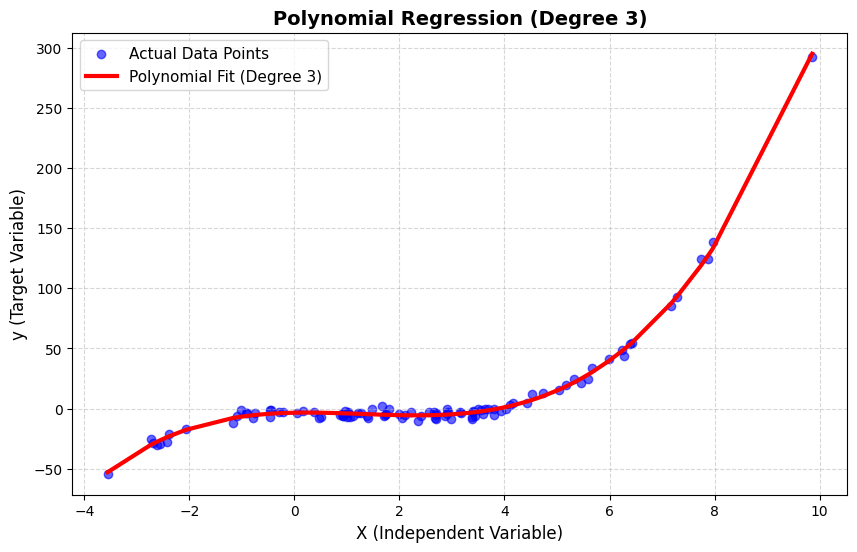

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Generate dummy non-linear data (a curved wave)
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)

# Reshape for scikit-learn (needs 2D array)
X = X[:, np.newaxis]

# 2. Transform features to Polynomial (Degree 3)
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 3. Fit standard Linear Regression on the transformed data
model = LinearRegression()
model.fit(X_poly, y)

# 4. Predict
y_pred = model.predict(X_poly)

print("Trained Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# ==========================================
# 5. SORT AND PLOT THE RESULTS
# ==========================================
# Sort X and y_pred together so the plot line flows smoothly from left to right
sorted_zip = sorted(zip(X.flatten(), y_pred))
X_sorted, y_pred_sorted = zip(*sorted_zip)

plt.figure(figsize=(10, 6))

# Plot the original noisy data points
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data Points')

# Plot the smooth fitted polynomial regression curve
plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=3, label='Polynomial Fit (Degree 3)')

# Add labels, title, and legend
plt.title('Polynomial Regression (Degree 3)', fontsize=14, fontweight='bold')
plt.xlabel('X (Independent Variable)', fontsize=12)
plt.ylabel('y (Target Variable)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot window
plt.show()
